      SubEDINScore  SubSTAIScore  Suicidality  CMAE04a1a  CMAE04a1b  \
0                1             1            1        0.0        0.0   
1                0             1            0        1.0        0.0   
2                0             0            0        0.0        0.0   
3                0             0            0        0.0        0.0   
4                0             1            0        0.0        0.0   
...            ...           ...          ...        ...        ...   
7785             1             1            1        1.0        1.0   
7786             0             0            0        1.0        0.0   
7787             0             0            0        0.0        0.0   
7788             0             1            0        0.0        0.0   
7789             0             1            0        0.0        0.0   

      CMAE04a1c  CMAE04a2a  CMAE04a2b  CMAE04a2c  ADHD  OCD  panic disorder  
0           0.0        0.0        0.0        0.0     0    0          

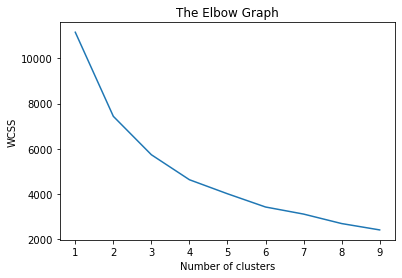

In [2]:
import numpy as np
import pandas as pd

from sklearn import datasets
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from pathlib import Path 
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.mplot3d import Axes3D

csv = Path("kmeans").with_name('Markers.CSV')
x = pd.read_csv(csv)

data = x
# data.drop(columns=["PublicID"], inplace=True)  #dropping non int columns
data.drop(columns=["Unnamed: 0"], inplace=True)
data = data.fillna(0) # Have to double check this
data.drop(columns=["clusters"], inplace=True)

# print(data)
wcss = [] #sum of square

print(data)
from sklearn.preprocessing import OneHotEncoder
enc = OneHotEncoder()
x_onehot = enc.fit_transform(data).toarray()

for i in range(1,10):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42).fit(x_onehot)
    wcss.append(kmeans.inertia_)
    
plt.plot(range(1,10),wcss)
plt.title('The Elbow Graph')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

# plt.scatter(x_onehot[:, 0], x_onehot[:, 1], c='red')
# plt.show()

# plt.scatter(x_onehot['x'], x['y'], c=data['binary_variable'])


# kmeans = KMeans(n_clusters=8, init ='k-means++', random_state=1234)
# y_kmeans = kmeans.fit_predict(x)
# plt.figure(figsize=(10,10))

# plt.scatter(x[:, 0], x[:, 0], c='red')
# plt.scatter(x[:, 1], x[:, 1], c='blue')
# plt.scatter(x[:, 2], x[:, 2], c='green')
# plt.scatter(x[:, 3], x[:, 3], c='magenta')

# plt.show()

# bins = np.linspace(x.min(), x.max(), 101) # 100 equally-sized intervals
# plt.xticks(bins, rotation=90)
# plt.scatter(x[y_kmeans==0, 0], x[y_kmeans==0, 1], s=100, c='red', label ='Cluster 1')
# plt.scatter(x[y_kmeans==1, 0], x[y_kmeans==1, 1], s=100, c='blue', label ='Cluster 2')
# plt.scatter(x[y_kmeans==2, 0], x[y_kmeans==2, 1], s=100, c='green', label ='Cluster 3')
# plt.scatter(x[y_kmeans==3, 0], x[y_kmeans==3, 1], s=100, c='cyan', label ='Cluster 4')
# plt.scatter(x[y_kmeans==4, 0], x[y_kmeans==4, 1], s=100, c='magenta', label ='Cluster 5')
# plt.scatter(x[y_kmeans==5, 0], x[y_kmeans==5, 1], s=100, c='black', label ='Cluster 6')
# plt.scatter(x[y_kmeans==6, 0], x[y_kmeans==6, 1], s=100, c='olive', label ='Cluster 7')
# plt.scatter(x[y_kmeans==7, 0], x[y_kmeans==7, 1], s=100, c='brown', label ='Cluster 8')

# plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='yellow', label = 'Centroids')
# plt.title('Clusters ')
# plt.xlabel('x')
# plt.ylabel('y')
# plt.show()


# #Optinum clusters via plotting looks to be 8 
# """
# kmeans_pca = KMeans(n_clusters = 8, init = 'k-means++', random_state=42)
# kmeans_pca.fit(scoresPCA)
# dfkmeans = pd.concat([df.reset_index(drop=True),pd.DataFrame(scoresPCA)], axis=1)
# dfkmeans.columns.values[-3: ] = ['Component 1', 'Component 2', 'Component 3']
# dfkmeans['Segment K-means'] = kmeans_pca.labels_
# print(dfkmeans.head())
# """

In [6]:
import numpy as np
from sklearn.cluster import SpectralClustering
from sklearn.metrics import pairwise_distances
from sklearn.preprocessing import StandardScaler

# Convert the pandas DataFrame to a NumPy array
# data = data.values

# Apply feature scaling to the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

# Define the number of clusters
n_clusters = 6

# Calculate the pairwise Jaccard similarities
jaccard_similarities = pairwise_distances(scaled_data, metric='jaccard')

# Perform Spectral Clustering on the Jaccard similarity matrix
spectral_clustering = SpectralClustering(n_clusters=n_clusters, affinity='precomputed')
labels = spectral_clustering.fit_predict(jaccard_similarities)

# Evaluate the similarity between patients in each cluster
for i in range(n_clusters):
    cluster_indices = np.where(labels == i)[0]
    cluster_similarity = np.mean(jaccard_similarities[np.ix_(cluster_indices, cluster_indices)])
    if cluster_similarity != 0:
        print(f'Cluster {i} mean Jaccard similarity: {cluster_similarity:.2f}')
    print(i)

C:\Users\91799\anaconda3\lib\site-packages\sklearn\metrics\pairwise.py:1776: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)
C:\Users\91799\anaconda3\lib\site-packages\sklearn\manifold\_spectral_embedding.py:245: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn("Graph is not fully connected, spectral embedding"


0
1
2
3


In [3]:
print(data.shape)

(7790, 12)


In [10]:
for i in range(len(kmeans.labels_)):
    cluster_size = len(kmeans.labels_[kmeans.labels_ == i])
    print('Number of records in cluster {}: {}'.format(i, cluster_size))


Number of records in cluster 0: 308
Number of records in cluster 1: 4724
Number of records in cluster 2: 648
Number of records in cluster 3: 1072
Number of records in cluster 4: 138
Number of records in cluster 5: 329
Number of records in cluster 6: 373
Number of records in cluster 7: 124
Number of records in cluster 8: 74
Number of records in cluster 9: 0
Number of records in cluster 10: 0
Number of records in cluster 11: 0
Number of records in cluster 12: 0
Number of records in cluster 13: 0
Number of records in cluster 14: 0
Number of records in cluster 15: 0
Number of records in cluster 16: 0
Number of records in cluster 17: 0
Number of records in cluster 18: 0
Number of records in cluster 19: 0
Number of records in cluster 20: 0
Number of records in cluster 21: 0
Number of records in cluster 22: 0
Number of records in cluster 23: 0
Number of records in cluster 24: 0
Number of records in cluster 25: 0
Number of records in cluster 26: 0
Number of records in cluster 27: 0
Number of r

Number of records in cluster 1099: 0
Number of records in cluster 1100: 0
Number of records in cluster 1101: 0
Number of records in cluster 1102: 0
Number of records in cluster 1103: 0
Number of records in cluster 1104: 0
Number of records in cluster 1105: 0
Number of records in cluster 1106: 0
Number of records in cluster 1107: 0
Number of records in cluster 1108: 0
Number of records in cluster 1109: 0
Number of records in cluster 1110: 0
Number of records in cluster 1111: 0
Number of records in cluster 1112: 0
Number of records in cluster 1113: 0
Number of records in cluster 1114: 0
Number of records in cluster 1115: 0
Number of records in cluster 1116: 0
Number of records in cluster 1117: 0
Number of records in cluster 1118: 0
Number of records in cluster 1119: 0
Number of records in cluster 1120: 0
Number of records in cluster 1121: 0
Number of records in cluster 1122: 0
Number of records in cluster 1123: 0
Number of records in cluster 1124: 0
Number of records in cluster 1125: 0
N

Number of records in cluster 3003: 0
Number of records in cluster 3004: 0
Number of records in cluster 3005: 0
Number of records in cluster 3006: 0
Number of records in cluster 3007: 0
Number of records in cluster 3008: 0
Number of records in cluster 3009: 0
Number of records in cluster 3010: 0
Number of records in cluster 3011: 0
Number of records in cluster 3012: 0
Number of records in cluster 3013: 0
Number of records in cluster 3014: 0
Number of records in cluster 3015: 0
Number of records in cluster 3016: 0
Number of records in cluster 3017: 0
Number of records in cluster 3018: 0
Number of records in cluster 3019: 0
Number of records in cluster 3020: 0
Number of records in cluster 3021: 0
Number of records in cluster 3022: 0
Number of records in cluster 3023: 0
Number of records in cluster 3024: 0
Number of records in cluster 3025: 0
Number of records in cluster 3026: 0
Number of records in cluster 3027: 0
Number of records in cluster 3028: 0
Number of records in cluster 3029: 0
N

Number of records in cluster 5302: 0
Number of records in cluster 5303: 0
Number of records in cluster 5304: 0
Number of records in cluster 5305: 0
Number of records in cluster 5306: 0
Number of records in cluster 5307: 0
Number of records in cluster 5308: 0
Number of records in cluster 5309: 0
Number of records in cluster 5310: 0
Number of records in cluster 5311: 0
Number of records in cluster 5312: 0
Number of records in cluster 5313: 0
Number of records in cluster 5314: 0
Number of records in cluster 5315: 0
Number of records in cluster 5316: 0
Number of records in cluster 5317: 0
Number of records in cluster 5318: 0
Number of records in cluster 5319: 0
Number of records in cluster 5320: 0
Number of records in cluster 5321: 0
Number of records in cluster 5322: 0
Number of records in cluster 5323: 0
Number of records in cluster 5324: 0
Number of records in cluster 5325: 0
Number of records in cluster 5326: 0
Number of records in cluster 5327: 0
Number of records in cluster 5328: 0
N

Number of records in cluster 6988: 0
Number of records in cluster 6989: 0
Number of records in cluster 6990: 0
Number of records in cluster 6991: 0
Number of records in cluster 6992: 0
Number of records in cluster 6993: 0
Number of records in cluster 6994: 0
Number of records in cluster 6995: 0
Number of records in cluster 6996: 0
Number of records in cluster 6997: 0
Number of records in cluster 6998: 0
Number of records in cluster 6999: 0
Number of records in cluster 7000: 0
Number of records in cluster 7001: 0
Number of records in cluster 7002: 0
Number of records in cluster 7003: 0
Number of records in cluster 7004: 0
Number of records in cluster 7005: 0
Number of records in cluster 7006: 0
Number of records in cluster 7007: 0
Number of records in cluster 7008: 0
Number of records in cluster 7009: 0
Number of records in cluster 7010: 0
Number of records in cluster 7011: 0
Number of records in cluster 7012: 0
Number of records in cluster 7013: 0
Number of records in cluster 7014: 0
N

In [4]:
pip install kmodes

Note: you may need to restart the kernel to use updated packages.


In [12]:
cluster_counts = {}
for label in kmeans.labels_:
    if label not in cluster_counts:
        cluster_counts[label] = 1
    else:
        cluster_counts[label] += 1

for cluster, count in cluster_counts.items():
    print('Number of records in cluster {}: {}'.format(cluster, count))


Number of records in cluster 2: 648
Number of records in cluster 0: 308
Number of records in cluster 1: 4724
Number of records in cluster 3: 1072
Number of records in cluster 5: 329
Number of records in cluster 6: 373
Number of records in cluster 4: 138
Number of records in cluster 8: 74
Number of records in cluster 7: 124


In [ ]:
import numpy as np
import pandas as pd
from kmodes.kmodes import KModes
from scipy.cluster.hierarchy import linkage, dendrogram

# Read the CSV file

# K-Modes Clustering
k = 5  # Number of clusters
# kmodes = KModes(n_clusters=k, init="Huang", n_init=20, verbose=1)
# kmodes.fit(data)

# Hierarchical Clustering
linkage_matrix = linkage(data, method="average")

# # Print cluster labels for K-Modes clustering
# print("K-Modes Clustering:")
# cluster_labels = kmodes.labels_
# cluster_labels_series = pd.Series(cluster_labels)
# print(cluster_labels_series.value_counts())

# for i, label in enumerate(kmodes.labels_):
#     print(f"Patient {i+1}: Cluster {label}")

# Plot the hierarchical clustering dendrogram
print("\nHierarchical Clustering:")
dendrogram(linkage_matrix, labels=data.index, leaf_rotation=90, leaf_font_size=8)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Patients")
plt.ylabel("Distance")
plt.show()
